# Large Scale Ambiguity Example

Generating examples of large scale ambiguities through SSD process 
- Two areas where SSD shows strong covergence: however two different locations 


CHECKLIST 
- [ ] Import new ground images and satellite imagery
- [ ] Register desired image to sat pt 1
- [ ] Register desired image to sat pt 2

In [1]:
from groundNAV_agent import gNAV_agent
# from microp_distb import microp_distb
# from distb_plt_utils import microp_distb_plotter

import pycolmap

import numpy as np
import open3d as o3d
import copy
import pickle

# SAVE YOUR WORK
%load_ext autoreload
%autoreload 2
%autosave 180

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Autosaving every 180 seconds


In [2]:
# Upload dataset inputs

# Colmap data
colm_fn = "../datasets/KBCB_colm/"

# Local test images 
# im_local = '../datasets/KBCB_test_images/' # With 10 local images 
# New local test image - frame 28599 NOT in COLMAP 
im_local = '../datasets/LSA_test_images/'


# Satellite reference image
# sat_ref = "../datasets/KBCB_satellite/KBCB_partial.jpg" # Public google earth satellite imagery
sat_ref = "../datasets/KBCB_satellite/KBCB_partial_LSA.png" # Public google earth satellite imagery



# Ground truth solutions
ind_params_KBCB = np.load("ind_params_KBCB_FULL.npy")

In [3]:
# Pose id for new frame
id_LSA = 121
# Starting scale and yaw from last KBCB ground truth solution
scale0, yaw0 = ind_params_KBCB[-1][0], ind_params_KBCB[-1][1]

# Candidate locations - satellite PIXEL coords (x, y) TODO: pick from KBCB_partial_LSA.png
sat_shift = np.array([700, 600]) # Same shift as sat_im_init
cands_px = {'A': (1000, 900),
            'B': (1500, 900)}
cand_params = {k: np.array([[scale0, yaw0, px - sat_shift[0], py - sat_shift[1]]])
               for k, (px, py) in cands_px.items()}

# Start with candidate A
ind_params = cand_params['A']

In [4]:
# Create class
gnav = gNAV_agent(colm_fn, im_local, sat_ref, ind_params)

# Borrow pose (image_parsing leaves unmatched ids at 0)
print("Parsed im_ids:", gnav.im_ids)
gnav.im_ids[0] = id_LSA
print("Borrowed:", gnav.im_ids, gnav.images_c[id_LSA].name)

Parsed im_ids: [0]
Borrowed: [121] frame_26999.jpg


#### Pose and GT solutions

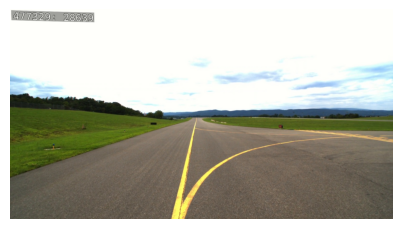

In [5]:
# VISUALIZER
gnav.visualize_local_ims()

In [6]:
# Using pre_calculated ground plane points - read explanation below 
pts_gnd_idx = np.load('../datasets/KBCB_params/ground_pts_idxs.npy')
gnav.pts_gnd_idx = pts_gnd_idx
# Run the ground plane extractor for visualization purposes 
pts_gnd_idx_test = gnav.get_gnd_pts() 
# # Visualize ground plane points 
# gnav.visualize_ground_pts(pts_gnd_idx_test) # UNCOMMENT for visualizations 

### Set ref frame

In [7]:
# Gather reference frame
tform_ref_frame = gnav.set_ref_frame() 
tform_ref_frame_pts = gnav.inv_homog_transform(tform_ref_frame)
gnav.tform_ref_frame_pts = tform_ref_frame_pts
print("\nReference frame transformation\n", tform_ref_frame_pts)

# Transform all points to the new coordinate system - for visual check 
tform_ref_frame_inv = gnav.inv_homog_transform(tform_ref_frame)
origin_ref, scene_pts_ref, scene_vec_ref = gnav.unit_vec_tform(gnav.scene_pts, gnav.origin_w, tform_ref_frame_inv)
gnav.scene_pts_ref = scene_pts_ref

Gravity vector 
 [-0.00516537  0.99923869  0.03866977]

Height h_0 =  0.09328363092429819

Reference frame transformation
 [[ 0.61692741  0.03361836 -0.7863017   0.20779018]
 [-0.7870031   0.01979491 -0.6166314  -0.15853791]
 [-0.00516537  0.99923869  0.03866977  0.90871723]
 [ 0.          0.          0.          1.        ]]


In [8]:
# Visualizer
gnav.visualize_ref_frame(scene_pts_ref)
# Optionally, view the direction of the gravity vector
# gnav.visualize_grav_vec()

878 1600 ytot xtot


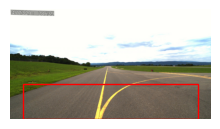

In [76]:
%matplotlib qt
# Prune points and create mask
# pts = gnav.prune_satellite_image()

# AUTOMATED PATCH EXTRACTION 
%matplotlib inline
# Initial size
params_tot = gnav.get_initial_params()
# Grab points and plot
gnav.grab_image_pts_tot(params_tot)
gnav.plot_gnd_pts()

In [10]:
# Generate projection of image sections 
for i in range(gnav.im_num):
    # Unit vectors in camera coords 
    pts_vec_c, pts_rgb_gnd = gnav.unit_vec_c(i)
    gnav.im_mosaic[i] = {'rgbc': pts_rgb_gnd}

    # Get transformation matrix that move from camera coords to world coords
    image_id = gnav.im_ids[i]
    # print(image_id)
    homog_w2c, homog_c2w = gnav.get_pose_id(image_id,i)
    # print('Homogeneous transformation from world to camera \n', homog_c2w)
    # print('\n Homogeneous transformation from camera to world \n', homog_w2c)

    # Transform to world coords
    origin_c, pts_loc_w, pts_vec_w = gnav.unit_vec_tform(pts_vec_c, gnav.origin_w, homog_c2w)
    # print('\n New camera frame origin = ', origin_c)
    
    # Get new points 
    ranges, new_pts_w = gnav.pt_range(pts_vec_w, homog_c2w, origin_c, i)
    # print('\nNew Points \n', new_pts_w)

    # Transfer points to reference frame
    __, new_pts_r, pts_vec_r = gnav.unit_vec_tform(new_pts_w, gnav.origin_w, gnav.tform_ref_frame_pts)

    # Convert points to grayscale 
    gray_c = gnav.conv_to_gray(gnav.im_mosaic[i]['rgbc'],i)
    # print(gray_c)

    # Put new points and grayscale colors in image mosaic
    gnav.im_mosaic[i]['pts'] = new_pts_r
    gnav.im_mosaic[i]['color_g'] = gray_c
    
    print("\nDone image ", i)


Done image  0


In [100]:
# Hand tuning: scale, rotation (deg), x, y - x, y in shifted sat frame (pixel - [700, 600])
scale, rot_deg, x, y = 140, 342, 760, 575

params_tune = np.array([[scale, np.deg2rad(rot_deg), x, y]])
gnav.implement_guess_ind(params_tune)

vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Image patch with reference map (tuning)")
gnav.mosaic_w_ref_visualization(vis)


In [70]:
# SSD at hand-aligned locations
# Each entry: scale, rotation (deg), x, y - same as tuning cell
locs = {'loc1': (140, 336, 322, 320), 'loc2': (140, 335, 1565, 952)}

n_ssd = 5
ssds_locs = {}

for key, (scale, rot_deg, x, y) in locs.items():
    params = np.array([[scale, np.deg2rad(rot_deg), x, y]])
    gnav.implement_guess_ind(params)
    ssds_locs[key] = gnav.ssd_nxn(n_ssd, 0)
    # Min SSD and shift (ssds indexed [shiftx + n, shifty + n])
    idx = np.unravel_index(np.argmin(ssds_locs[key]), ssds_locs[key].shape)
    print(f"{key}: min SSD = {ssds_locs[key][idx]:.2f} at shift (x, y) = ({idx[0]-n_ssd}, {idx[1]-n_ssd})")


Number of points used for image 0:  (3902,)
loc1: min SSD = 17.72 at shift (x, y) = (-2, 0)
Number of points used for image 0:  (3897,)
loc2: min SSD = 22.52 at shift (x, y) = (4, 3)


In [104]:
import plotly.graph_objects as go

# SSD surface plots (plotly) for each location
x = np.linspace(-n_ssd, n_ssd, 2*n_ssd + 1)
Y, X = np.meshgrid(x, x) # ssds indexed [shiftx + n, shifty + n]

for key, ssds in ssds_locs.items():
    # Min SSD
    idrow, idcol = np.unravel_index(np.argmin(ssds), ssds.shape)
    print(f"BEST SHIFT for {key}:", idrow - n_ssd, idcol - n_ssd)

    fig = go.Figure()

    # SSD surface
    fig.add_surface(x=X, y=Y, z=ssds, colorscale='Viridis',
                    colorbar=dict(title='SSD'), name='SSD Surface')

    # Min SSD point
    fig.add_trace(go.Scatter3d(x=[idrow - n_ssd], y=[idcol - n_ssd], z=[ssds[idrow, idcol]],
                               mode='markers', marker=dict(size=6, color='red'), name='Min SSD'))

    # Aligned location (zero shift)
    fig.add_trace(go.Scatter3d(x=[0], y=[0], z=[ssds[n_ssd, n_ssd]],
                               mode='markers', marker=dict(size=6, color='black'), name='Hand aligned'))

    fig.update_layout(
        title=f'SSD Surface Plot: {key} {locs[key]}',
        scene=dict(
            xaxis=dict(title='X Shift (pixels)', range=[-n_ssd, n_ssd], dtick=1),
            yaxis=dict(title='Y Shift (pixels)', range=[-n_ssd, n_ssd], dtick=1),
            zaxis=dict(title='SSD'),
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.2)),
            aspectmode='cube'
        ),
        width=900, height=800
    )
    fig.show()


BEST SHIFT for loc1: -2 0


BEST SHIFT for loc2: 4 3


BEST SHIFT for loc3_orig: -1 1


In [79]:
import cv2
# Swap satellite reference on existing agent (projection unchanged)
sat_ref_orig = "../datasets/KBCB_satellite/KBCB_partial.jpg"
gnav.sat_ref_c = cv2.imread(sat_ref_orig)
gnav.sat_ref = cv2.cvtColor(gnav.sat_ref_c, cv2.COLOR_BGR2GRAY)
gnav.sat_im_init() # Rebuilds ref_pts, ref_rgb (same [700, 600] shift)
print("Satellite:", gnav.sat_ref.shape)


Satellite: (1239, 1783)


In [103]:
# SSD on original satellite image
locs['loc3_orig'] = (140, 342, 760, 575) # TODO: tuned values from cell 15

scale, rot_deg, x, y = locs['loc3_orig']
gnav.implement_guess_ind(np.array([[scale, np.deg2rad(rot_deg), x, y]]))
ssds_locs['loc3_orig'] = gnav.ssd_nxn(n_ssd, 0)

idx = np.unravel_index(np.argmin(ssds_locs['loc3_orig']), ssds_locs['loc3_orig'].shape)
print(f"loc3_orig: min SSD = {ssds_locs['loc3_orig'][idx]:.2f} at shift (x, y) = ({idx[0]-n_ssd}, {idx[1]-n_ssd})")


Number of points used for image 0:  (3897,)
loc3_orig: min SSD = 22.12 at shift (x, y) = (-1, 1)


In [11]:
gnav.patch_mask_refine()
# Crop based on mask
gnav.patch_mask_crop(range_num = 2.5)

AttributeError: 'gNAV_agent' object has no attribute 'pts_select_sat'

In [ ]:
# VISUALIZERS
# Just the satellite map and colmap scene
gnav.visualize_sat_cmap_scene()
# Colmap scene, and MASK (optional satellite)
gnav.visualize_sat_cmap_scene_mask()

In [ ]:
# PLOTTING THE NEW SCENE MOSAIC

# Use open3d to create point cloud visualization 
# Create visualization 
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Mosaic scene with satellite reference")

# Create axes @ origin
axis_origin = o3d.geometry.TriangleMesh.create_coordinate_frame(size=1)

# If we just want to look at specific images
specified_clouds = np.array([0,1,2,3,4,5,7,8,9])

# for i in specified_clouds:
for i in range(gnav.im_num):
    print(i)
    cloud = o3d.geometry.PointCloud()
    cloud.points = o3d.utility.Vector3dVector(gnav.im_mosaic[i]['pts'])
    cloud.colors = o3d.utility.Vector3dVector(gnav.im_mosaic[i]['color_g'])
    vis.add_geometry(cloud)

scene_cloud = o3d.geometry.PointCloud()
scene_cloud.points = o3d.utility.Vector3dVector(gnav.scene_pts_ref)
scene_cloud.colors = o3d.utility.Vector3dVector(gnav.scene_rgb)
vis.add_geometry(scene_cloud)

# Create point cloud for reference cloud (satellite)
ref_cloud = o3d.geometry.PointCloud()
# ref_cloud.points = o3d.utility.Vector3dVector(gnav.ref_pts)
ref_cloud.points = o3d.utility.Vector3dVector(gnav.sat_pts_adj)
ref_cloud.colors = o3d.utility.Vector3dVector(gnav.ref_rgb)

# Add necessary geometries to visualization 
vis.add_geometry(axis_origin)
vis.add_geometry(ref_cloud)


# Run and destroy visualization 
vis.run()
vis.destroy_window()

In [ ]:
import pycolmap, re
recon = pycolmap.Reconstruction("../datasets/KBCB_colm")
regs = sorted((int(re.search(r"\d+", im.name).group()), im_id, im.name)
              for im_id, im in recon.images.items())
print(len(regs), "registered:", regs[0][2], "...", regs[-1][2])
nearest = min(regs, key=lambda r: abs(r[0] - 28599))
print("nearest:", nearest)   # (frame_num, colmap_id, name)
